# E-Commerce Sales Analysis — Olist Brazilian E-Commerce Dataset
**Project 01 | Data Analytics Internship Program**

This notebook covers: data cleaning, the 5 required sales-analysis questions, and the 6 required visualisations.
Place the Olist CSV files in a `data/` folder next to this notebook before running.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.width', 120)
plt.rcParams["font.family"] = "DejaVu Sans"
DATA = "data"


## 1. Data Cleaning

### 1.1 Load all source files

In [2]:
orders = pd.read_csv(f"{DATA}/olist_orders_dataset.csv")
items = pd.read_csv(f"{DATA}/olist_order_items_dataset.csv")
products = pd.read_csv(f"{DATA}/olist_products_dataset.csv")
reviews = pd.read_csv(f"{DATA}/olist_order_reviews_dataset.csv")
customers = pd.read_csv(f"{DATA}/olist_customers_dataset.csv")
cat_trans = pd.read_csv(f"{DATA}/product_category_name_translation.csv")

print(f"orders: {orders.shape}")
print(f"items: {items.shape}")
print(f"products: {products.shape}")
print(f"reviews: {reviews.shape}")
print(f"customers: {customers.shape}")
print(f"category translation: {cat_trans.shape}")


orders: (99441, 8)
items: (112650, 7)
products: (32951, 9)
reviews: (99224, 7)
customers: (99441, 5)
category translation: (71, 2)


### 1.2 Check missing values
**Decisions documented as we go — this is graded, not just a formality.**

In [3]:
for name, d in [("orders",orders),("items",items),("products",products),
                ("reviews",reviews),("customers",customers)]:
    miss = d.isnull().sum()
    miss = miss[miss > 0]
    print(f"{name}: {dict(miss) if len(miss) else 'no missing values'}")


orders: {'order_approved_at': np.int64(160), 'order_delivered_carrier_date': np.int64(1783), 'order_delivered_customer_date': np.int64(2965)}
items: no missing values
products: {'product_category_name': np.int64(610), 'product_name_lenght': np.int64(610), 'product_description_lenght': np.int64(610), 'product_photos_qty': np.int64(610), 'product_weight_g': np.int64(2), 'product_length_cm': np.int64(2), 'product_height_cm': np.int64(2), 'product_width_cm': np.int64(2)}
reviews: {'review_comment_title': np.int64(87656), 'review_comment_message': np.int64(58247)}
customers: no missing values


**Cleaning decisions:**
- `orders`: `order_approved_at` / `order_delivered_carrier_date` / `order_delivered_customer_date` are missing
  only for orders that were never approved/shipped/delivered (status = canceled/unavailable/etc). We keep
  these rows for status context but filter to `delivered` orders only before revenue analysis.
- `products`: 610 rows have no `product_category_name`. Dropping them would silently lose real revenue,
  so they're relabelled `"unknown_category"` instead of removed.
- `reviews`: `review_comment_title`/`review_comment_message` are optional free text — missing values here
  simply mean the customer didn't write a comment, not a data quality problem. `review_score` itself has
  zero missing values, so no action needed on the metric we actually analyse.

In [4]:
orders["order_status"] = orders["order_status"].str.lower().str.strip()
products["product_category_name"] = products["product_category_name"].fillna("unknown_category")


### 1.3 Fix data types

In [5]:
date_cols = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date",
             "order_delivered_customer_date","order_estimated_delivery_date"]
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
reviews["review_score"] = reviews["review_score"].astype(int)
items["price"] = items["price"].astype(float)
items["freight_value"] = items["freight_value"].astype(float)

print(orders[date_cols].dtypes)


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


### 1.4 Remove duplicates

In [6]:
before = len(orders); orders = orders.drop_duplicates(subset="order_id")
print(f"orders: removed {before-len(orders)} duplicate order_id rows")

before = len(items); items = items.drop_duplicates()
print(f"items: removed {before-len(items)} exact duplicate rows")

before = len(products); products = products.drop_duplicates(subset="product_id")
print(f"products: removed {before-len(products)} duplicate product_id rows")

before = len(reviews); reviews = reviews.drop_duplicates(subset="review_id")
print(f"reviews: removed {before-len(reviews)} duplicate review_id rows")

before = len(customers); customers = customers.drop_duplicates(subset="customer_id")
print(f"customers: removed {before-len(customers)} duplicate customer_id rows")


orders: removed 0 duplicate order_id rows


items: removed 0 exact duplicate rows
products: removed 0 duplicate product_id rows
reviews: removed 814 duplicate review_id rows
customers: removed 0 duplicate customer_id rows


**Decision:** an order can have more than one review row (customer re-reviews after a follow-up).
For a clean 1-row-per-order analysis we keep only the *most recent* review per `order_id`.

In [7]:
before = len(reviews)
reviews = reviews.sort_values("review_creation_date").drop_duplicates(subset="order_id", keep="last")
print(f"reviews: kept latest review per order, removed {before-len(reviews)} extra rows")


reviews: kept latest review per order, removed 243 extra rows

### 1.5 Translate category names to English and merge all tables

In [8]:
products = products.merge(cat_trans, on="product_category_name", how="left")
products["product_category_name_english"] = products["product_category_name_english"].fillna(
    products["product_category_name"])

df = orders.merge(items, on="order_id", how="inner")
print(f"orders + items (inner join, transaction grain): {df.shape[0]} rows")

df = df.merge(products[["product_id","product_category_name_english"]], on="product_id", how="left")
df = df.merge(customers[["customer_id","customer_state","customer_city"]], on="customer_id", how="left")
df = df.merge(reviews[["order_id","review_score"]], on="order_id", how="left")
print(f"Final merged table: {df.shape[0]} rows, {df.shape[1]} columns")


orders + items (inner join, transaction grain): 112650 rows


Final merged table: 112650 rows, 18 columns


### 1.6 Scope the analysis to completed sales
**Decision:** keep only `order_status == 'delivered'` — cancelled/returned/pending orders don't represent
real completed revenue and would distort every KPI below.

In [9]:
before = len(df)
df = df[df["order_status"] == "delivered"].copy()
df = df.dropna(subset=["order_purchase_timestamp"])
print(f"Kept {len(df)} of {before} rows after filtering to delivered orders with a valid purchase date")

df["revenue"] = df["price"] + df["freight_value"]
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
print(f"Date range: {df['order_purchase_timestamp'].min()} to {df['order_purchase_timestamp'].max()}")


Kept 110197 of 112650 rows after filtering to delivered orders with a valid purchase date
Date range: 2016-09-15 12:16:38 to 2018-08-29 15:00:37


**Decision:** two months (`2016-09`, `2016-12`) have fewer than 50 orders — these are Olist's platform
ramp-up period, not representative sales months. They're kept in the data (not deleted) but excluded from
month-over-month comparisons like "peak month" so a near-empty test month doesn't distort the answer.

In [10]:
monthly_counts = df.groupby("order_month")["order_id"].nunique().sort_index()
flagged_months = monthly_counts[monthly_counts < 50].index.tolist()
print("Flagged low-volume months:", flagged_months)


Flagged low-volume months: ['2016-09', '2016-12']


## 2. Sales Analysis — 5 Questions

### Q1: Which product category has the highest revenue?

In [11]:
cat_rev = df.groupby("product_category_name_english")["revenue"].sum().sort_values(ascending=False)
print(cat_rev.head(10))
print(f"\nANSWER: {cat_rev.idxmax()} — R$ {cat_rev.max():,.2f}")


product_category_name_english
health_beauty            1412089.53
watches_gifts            1264333.12
bed_bath_table           1225209.26
sports_leisure           1118256.91
computers_accessories    1032723.77
furniture_decor           880329.92
housewares                758392.25
cool_stuff                691680.89
auto                      669454.75
garden_tools              567145.68
Name: revenue, dtype: float64

ANSWER: health_beauty — R$ 1,412,089.53


### Q2: Which month had peak sales?

In [12]:
monthly = df.groupby("order_month")["revenue"].sum().sort_index()
monthly_full = monthly[~monthly.index.isin(flagged_months)]
print(monthly)
print(f"\nANSWER (excluding ramp-up months): {monthly_full.idxmax()} — R$ {monthly_full.max():,.2f}")


order_month
2016-09        143.46
2016-10      46490.66
2016-12         19.62
2017-01     127482.37
2017-02     271239.32
2017-03     414330.95
2017-04     390812.40
2017-05     566851.40
2017-06     490050.37
2017-07     566299.08
2017-08     645832.36
2017-09     701077.49
2017-10     751117.01
2017-11    1153364.20
2017-12     843078.29
2018-01    1077887.46
2018-02     966168.41
2018-03    1120598.24
2018-04    1132878.93
2018-05    1128774.52
2018-06    1011978.29
2018-07    1027807.28
2018-08     985491.64
Name: revenue, dtype: float64

ANSWER (excluding ramp-up months): 2017-11 — R$ 1,153,364.20


### Q3: Which region performs best?

In [13]:
reg_rev = df.groupby("customer_state")["revenue"].sum().sort_values(ascending=False)
reg_orders = df.groupby("customer_state")["order_id"].nunique().sort_values(ascending=False)
print("Revenue by state (top 10):"); print(reg_rev.head(10))
print("\nOrders by state (top 5):"); print(reg_orders.head())
print(f"\nANSWER: {reg_rev.idxmax()} (São Paulo) — R$ {reg_rev.max():,.2f}, {reg_orders[reg_rev.idxmax()]:,} orders")


Revenue by state (top 10):
customer_state
SP    5769703.15
RJ    2055401.57
MG    1818891.67
RS     861472.79
PR     781708.80
SC     595127.78
BA     591137.81
DF     346123.35
GO     334212.35
ES     317657.93
Name: revenue, dtype: float64

Orders by state (top 5):
customer_state
SP    40501
RJ    12350
MG    11354
RS     5345
PR     4923
Name: order_id, dtype: int64

ANSWER: SP (São Paulo) — R$ 5,769,703.15, 40,501 orders


### Q4: What is the average order value (AOV) trend?

In [14]:
aov = df.groupby("order_month").agg(revenue=("revenue","sum"), orders=("order_id","nunique"))
aov["aov"] = aov["revenue"] / aov["orders"]
print(aov.round(2))
aov_full = aov[~aov.index.isin(flagged_months)]
print(f"\nAOV range across full months: R$ {aov_full['aov'].min():.2f} - R$ {aov_full['aov'].max():.2f}")
print(f"AOV in first full month ({aov_full.index[0]}): R$ {aov_full['aov'].iloc[0]:.2f}")
print(f"AOV in last full month ({aov_full.index[-1]}): R$ {aov_full['aov'].iloc[-1]:.2f}")


                revenue  orders     aov
order_month                            
2016-09          143.46       1  143.46
2016-10        46490.66     265  175.44
2016-12           19.62       1   19.62
2017-01       127482.37     750  169.98
2017-02       271239.32    1653  164.09
2017-03       414330.95    2546  162.74
2017-04       390812.40    2303  169.70
2017-05       566851.40    3546  159.86
2017-06       490050.37    3135  156.32
2017-07       566299.08    3872  146.25
2017-08       645832.36    4193  154.03
2017-09       701077.49    4150  168.93
2017-10       751117.01    4478  167.73
2017-11      1153364.20    7289  158.23
2017-12       843078.29    5513  152.93
2018-01      1077887.46    7069  152.48
2018-02       966168.41    6555  147.39
2018-03      1120598.24    7003  160.02
2018-04      1132878.93    6798  166.65
2018-05      1128774.52    6749  167.25
2018-06      1011978.29    6099  165.93
2018-07      1027807.28    6159  166.88
2018-08       985491.64    6351  155.17


**ANSWER:** AOV has stayed relatively flat (roughly R$150–175) across the full two years, with no
strong upward or downward trend — order *volume* grew substantially over the period, but the average
basket size per order did not.

### Q5: What is the customer review score distribution?

In [15]:
rv_counts = df.drop_duplicates("order_id")["review_score"].value_counts().sort_index()
rv_pct = (rv_counts / rv_counts.sum() * 100).round(2)
print(rv_pct)
print(f"\nAverage review score: {df.drop_duplicates('order_id')['review_score'].mean():.2f} / 5")
print(f"ANSWER: {rv_pct[5]}% of orders receive 5 stars, but {rv_pct[1]+rv_pct[2]:.1f}% receive 1-2 stars")


review_score
1.0     9.71
2.0     3.04
3.0     8.25
4.0    19.74
5.0    59.26
Name: count, dtype: float64

Average review score: 4.16 / 5
ANSWER: 59.26% of orders receive 5 stars, but 12.8% receive 1-2 stars


## 3. Visualisations — 6 Required Charts

### Chart 1: Bar chart — Revenue by category

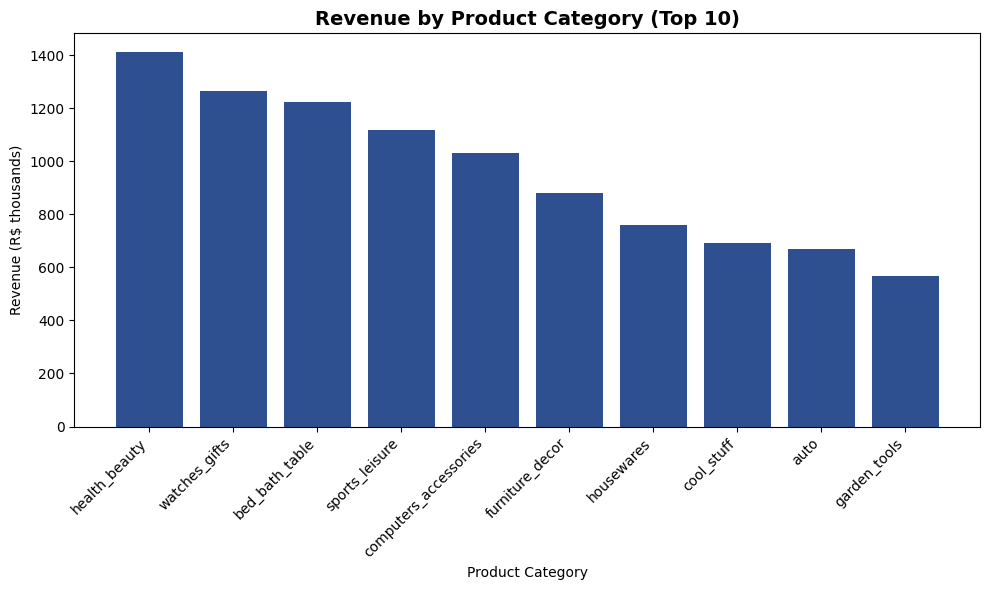

In [16]:
cat_rev_top10 = cat_rev.head(10)
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(cat_rev_top10.index, cat_rev_top10.values/1000, color="#2E5090")
ax.set_title("Revenue by Product Category (Top 10)", fontsize=14, fontweight="bold")
ax.set_xlabel("Product Category")
ax.set_ylabel("Revenue (R$ thousands)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Chart 2: Line chart — Monthly revenue trend

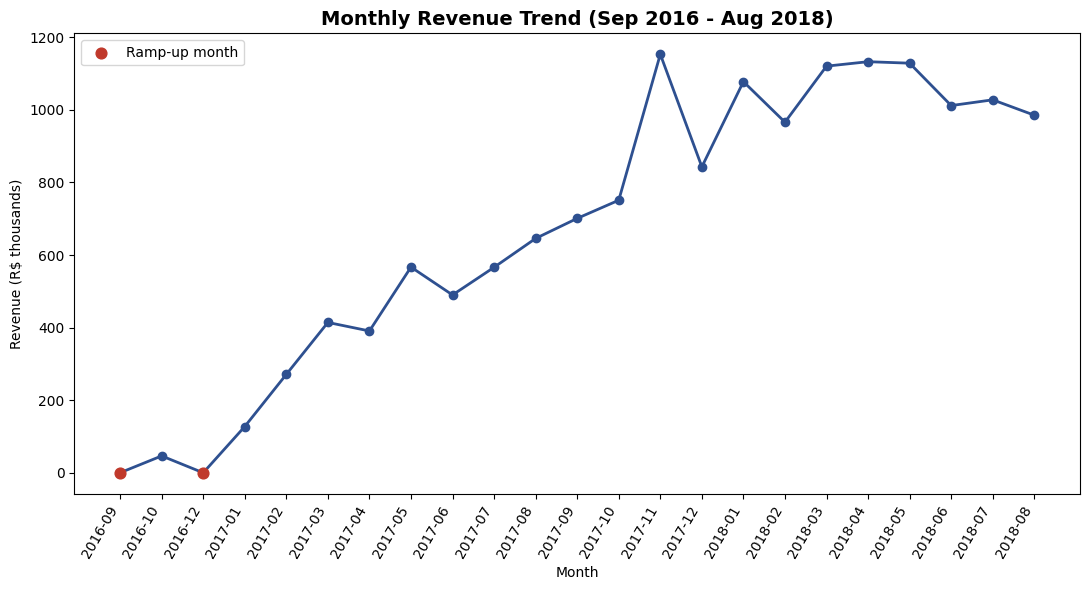

In [17]:
fig, ax = plt.subplots(figsize=(11,6))
ax.plot(monthly.index, monthly.values/1000, marker="o", color="#2E5090", linewidth=2)
for m in flagged_months:
    ax.scatter([m], [monthly[m]/1000], color="#C0392B", zorder=5, s=60, label="Ramp-up month" if m==flagged_months[0] else "")
ax.set_title("Monthly Revenue Trend (Sep 2016 - Aug 2018)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (R$ thousands)")
plt.xticks(rotation=60, ha="right")
ax.legend()
plt.tight_layout()
plt.show()


### Chart 3: Bar chart — Regional sales

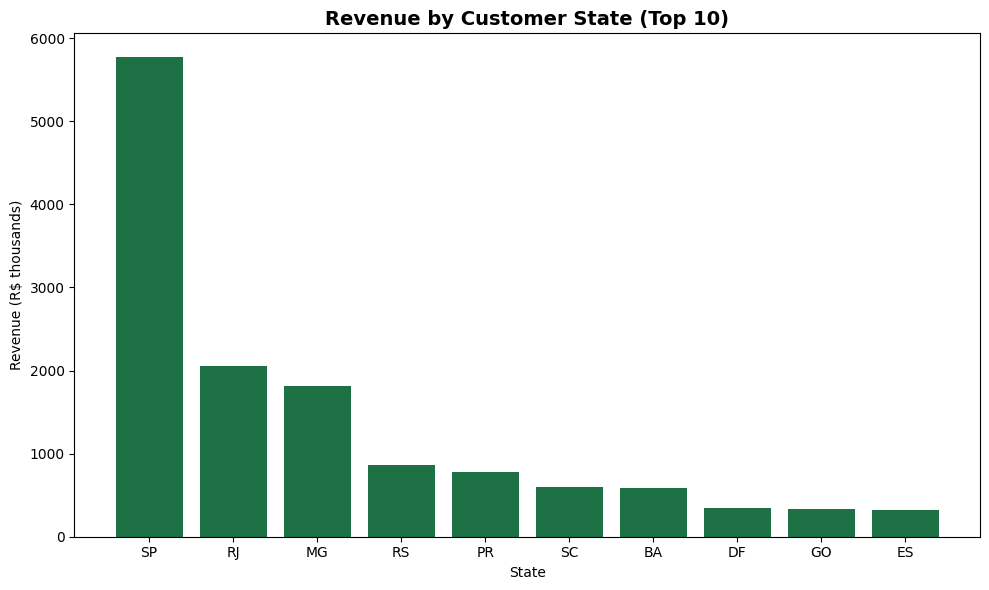

In [18]:
reg_rev_top10 = reg_rev.head(10)
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(reg_rev_top10.index, reg_rev_top10.values/1000, color="#1E7145")
ax.set_title("Revenue by Customer State (Top 10)", fontsize=14, fontweight="bold")
ax.set_xlabel("State")
ax.set_ylabel("Revenue (R$ thousands)")
plt.tight_layout()
plt.show()


### Chart 4: Histogram — Order values

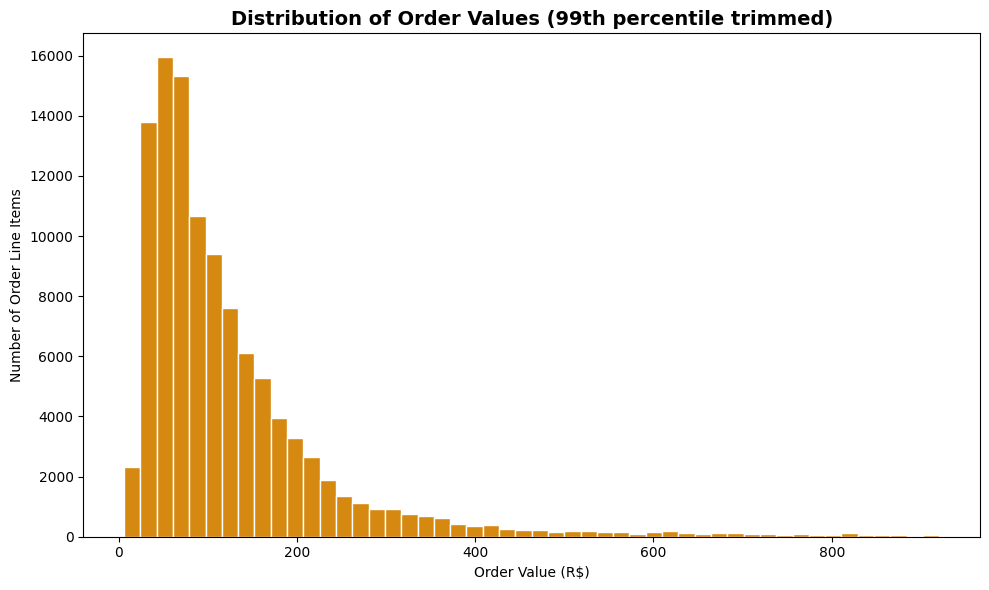

In [19]:
order_vals = df["revenue"]
fig, ax = plt.subplots(figsize=(10,6))
ax.hist(order_vals[order_vals < order_vals.quantile(0.99)], bins=50, color="#D68910", edgecolor="white")
ax.set_title("Distribution of Order Values (99th percentile trimmed)", fontsize=14, fontweight="bold")
ax.set_xlabel("Order Value (R$)")
ax.set_ylabel("Number of Order Line Items")
plt.tight_layout()
plt.show()


### Chart 5: Pie chart — Review score distribution

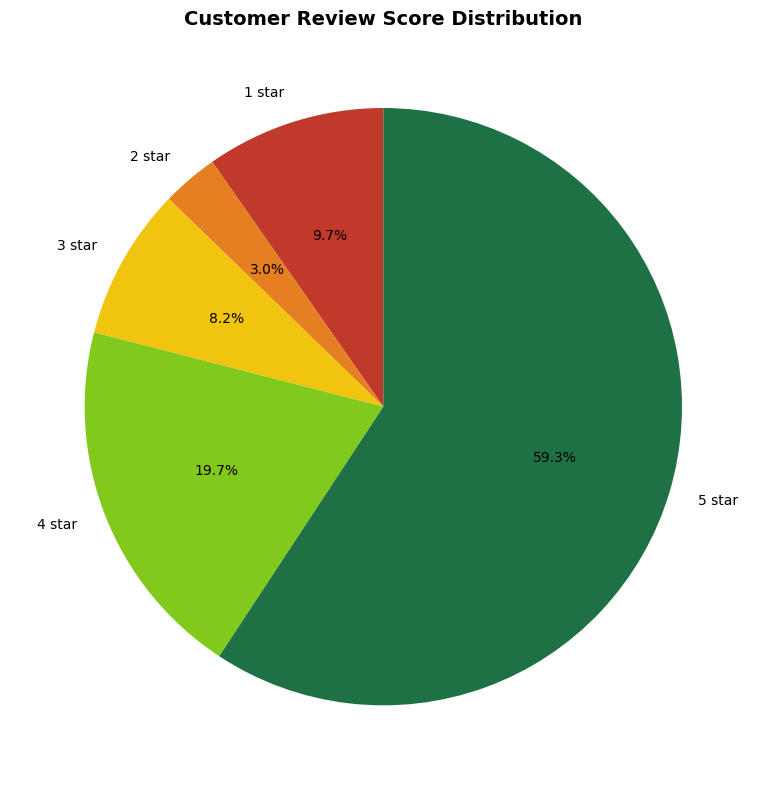

In [20]:
fig, ax = plt.subplots(figsize=(8,8))
colors5 = ["#C0392B","#E67E22","#F1C40F","#82C91E","#1E7145"]
ax.pie(rv_counts.values, labels=[f"{int(s)} star" for s in rv_counts.index], autopct="%1.1f%%",
       colors=colors5, startangle=90)
ax.set_title("Customer Review Score Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Chart 6: Heatmap — Category vs month

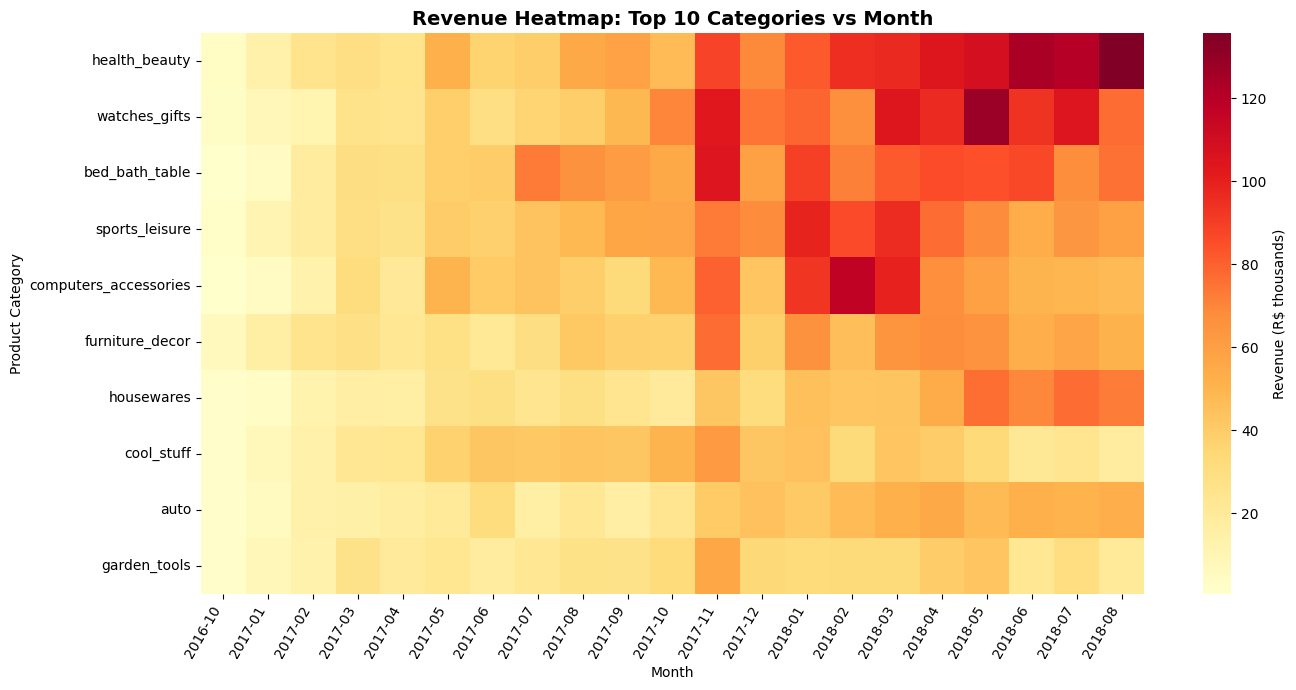

In [21]:
top10cats = cat_rev.head(10).index.tolist()
pivot = df[df["product_category_name_english"].isin(top10cats)].pivot_table(
    index="product_category_name_english", columns="order_month", values="revenue", aggfunc="sum", fill_value=0
)
pivot = pivot.reindex(top10cats)
pivot = pivot[[c for c in sorted(pivot.columns) if c not in flagged_months]]

fig, ax = plt.subplots(figsize=(14,7))
sns.heatmap(pivot/1000, cmap="YlOrRd", ax=ax, cbar_kws={"label":"Revenue (R$ thousands)"})
ax.set_title("Revenue Heatmap: Top 10 Categories vs Month", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Product Category")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


## Summary of Findings

1. **Top category:** Health & Beauty generates the highest revenue (~R$1.41M)
2. **Peak month:** November 2017 (~R$1.15M) — Black Friday effect
3. **Best region:** São Paulo (SP) — ~R$5.77M, more than double the second-place state
4. **AOV trend:** Flat around R$150–175 across the full period — growth is coming from volume, not basket size
5. **Reviews:** 59.3% of orders get 5 stars, but 12.75% get 1-2 stars — a meaningful dissatisfaction segment

See the separate Business Insights Report for the 5 numbered, recommendation-backed insights, and the
Excel dashboard for the manager-facing 1-page summary.